In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [2]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
df = pd.read_csv('../../datascience/data/processed/cleaned_df.csv')

In [ ]:
df_model = df.copy()
df_model = df_model.drop(
    columns=["StationId", "Date", "AQI_Bucket"],
    errors="ignore"
)
X = df_model.drop(columns=["AQI"])
y = df_model["AQI"]

X = X.select_dtypes(include=["number"])
print("X columns:")
print(X.columns.tolist())
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

X columns:
['Unnamed: 0', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'lat', 'lon']

Non-numeric columns:
[]


In [5]:
df.columns

Index(['Unnamed: 0', 'StationId', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
       'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket',
       'lat', 'lon'],
      dtype='str')

In [6]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
       'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene','lat', 'lon']

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['month'] = df['Date'].dt.month
df['Day_of_week'] = df['Date'].dt.day_of_week
df.head()

,Unnamed: 0,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,lat,lon,month,Day_of_week
0,0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,NaN,NaN,16.509668,80.518454,11,4
1,1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,184.0,Moderate,16.509668,80.518454,11,5
2,2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,197.0,Moderate,16.509668,80.518454,11,6
3,3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,198.0,Moderate,16.509668,80.518454,11,0
4,4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,188.0,Moderate,16.509668,80.518454,11,1


In [9]:
features += ['month' , 'Day_of_week']

In [10]:
features = ['PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'lat',
 'lon',
 'month',
 'Day_of_week']

In [11]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  108035 non-null  int64  
 1   PM2.5       108035 non-null  float64
 2   PM10        108035 non-null  float64
 3   NO          108035 non-null  float64
 4   NO2         108035 non-null  float64
 5   NOx         108035 non-null  float64
 6   NH3         108035 non-null  float64
 7   CO          108035 non-null  float64
 8   SO2         108035 non-null  float64
 9   O3          108035 non-null  float64
 10  Benzene     108035 non-null  float64
 11  Toluene     108035 non-null  float64
 12  AQI         87025 non-null   float64
 13  lat         108035 non-null  float64
 14  lon         108035 non-null  float64
dtypes: float64(14), int64(1)
memory usage: 12.4 MB


In [13]:
df_model.replace([np.inf, -np.inf], np.nan)

,Unnamed: 0,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,lat,lon
0,0,71.36,115.75,1.750000,20.650000,12.40,12.190000,0.10,10.76,109.26,0.17,5.92,NaN,16.509668,80.518454
1,1,81.40,124.50,1.440000,20.500000,12.08,10.720000,0.12,15.24,127.09,0.20,6.50,184.0,16.509668,80.518454
2,2,78.32,129.06,1.260000,26.000000,14.85,10.280000,0.14,26.96,117.44,0.22,7.95,197.0,16.509668,80.518454
3,3,88.76,135.32,6.600000,30.850000,21.77,12.910000,0.11,33.59,111.81,0.29,7.63,198.0,16.509668,80.518454
4,4,64.18,104.09,2.560000,28.070000,17.01,11.420000,0.09,19.00,138.18,0.17,5.02,188.0,16.509668,80.518454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108030,108030,8.65,16.46,20.223333,77.956667,98.08,20.526667,0.69,4.36,30.59,1.32,7.26,50.0,22.572646,88.363895
108031,108031,11.80,18.47,16.936667,139.413333,156.14,15.963333,0.68,3.49,38.95,1.42,7.92,65.0,22.572646,88.363895
108032,108032,18.60,32.26,13.650000,200.870000,214.20,11.400000,0.78,5.12,38.17,3.52,8.64,63.0,22.572646,88.363895
108033,108033,16.07,39.30,7.560000,29.130000,36.69,29.260000,0.69,5.88,29.64,1.86,8.40,57.0,22.572646,88.363895


In [14]:
df_model.isnull().sum()

Unnamed: 0        0
PM2.5             0
PM10              0
NO                0
NO2               0
NOx               0
NH3               0
CO                0
SO2               0
O3                0
Benzene           0
Toluene           0
AQI           21010
lat               0
lon               0
dtype: int64

In [ ]:
df_model = df.copy()

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=["AQI"])

X = df_model.drop(columns=["AQI", "StationId", "Date", "AQI_Bucket" , 'Unnamed:0'],
                  errors="ignore")

y = df_model["AQI"]
y = pd.to_numeric(y, errors="coerce")

mask = y.notna() & np.isfinite(y)

X = X.loc[mask]
y = y.loc[mask]

In [16]:
X = df_model[features]
y = df_model['AQI']

In [17]:
X_train , X_test , y_train , y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [18]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [19]:
y_train.isna().sum()

np.int64(0)

In [20]:
print("NaN:", y_train.isna().sum())
print("Inf:", np.isinf(y_train).sum())
print("Max:", y_train.max())
print("Min:", y_train.min())

NaN: 0
Inf: 0
Max: 2049.0
Min: 8.0


In [21]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [22]:
model.feature_importances_

array([0.46219778, 0.14437898, 0.02318152, 0.00882022, 0.02091895,
       0.01379428, 0.12640293, 0.01139306, 0.02384252, 0.00620598,
       0.00727187, 0.06226955, 0.05664961, 0.02794699, 0.00472585],
      dtype=float32)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 20.757150384168177
RMSE: 35.78788746203616
R² Score: 0.9258095417506952



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/py

AttributeError: _ARRAY_API not found

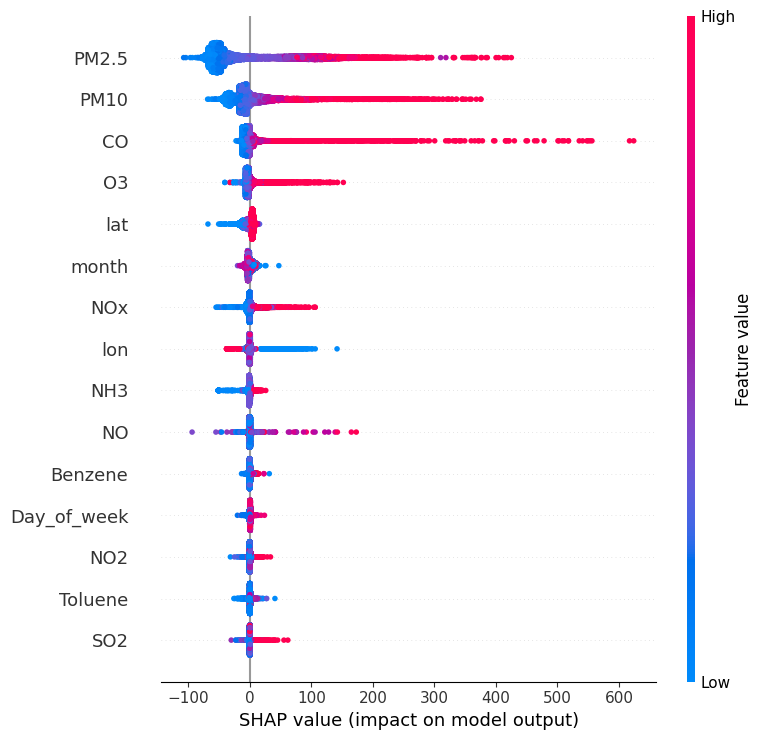

In [24]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [25]:
!pip install shap


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import joblib

joblib.dump(model , '../../models/aqi_xgboost.pkl')

['../../models/aqi_xgboost.pkl']

In [29]:
import pickle

with open("../../models/aqi_xgboost.pkl", "rb") as f:
    model = pickle.load(f)

print(model.get_booster().feature_names)

['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'lat', 'lon', 'month', 'Day_of_week']


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import pickle

FEATURES = ["lat", "lon", "PM2.5", "PM10", "NO2", "month", "day_of_week"]
TARGET = "AQI"

df = combined_aqi.dropna(subset=FEATURES + [TARGET])
X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=400, max_depth=7, learning_rate=0.05, subsample=0.8)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(f"Scaled AQI model — R²: {r2_score(y_test, preds):.3f}, MAE: {mean_absolute_error(y_test, preds):.2f}")

pickle.dump(model, open("models/aqi_xgboost_scaled.pkl", "wb"))

In [ ]:
import pandas as pd
import json

kaggle_df = pd.read_csv("datascience/data/processed/kaggle_aqi_training.csv")

with open("datascience/data/raw/cpcb/cpcb_backfill_progress.json") as f:
    live_data = json.load(f)
live_df = pd.DataFrame(live_data)

live_df["date"] = pd.to_datetime(live_df["date"].str[:10])

# one lat/lon per station
loc = live_df.groupby("location_name")[["lat", "lon"]].first().reset_index()

live_pivoted = live_df.pivot_table(
    index=["location_name", "date"], columns="parameter",
    values="value", aggfunc="mean"
).reset_index()
live_pivoted.columns.name = None

live_pivoted = live_pivoted.merge(loc, on="location_name")
live_pivoted = live_pivoted.rename(columns={
    "pm25": "PM2.5", "pm10": "PM10", "no2": "NO2",
    "so2": "SO2", "co": "CO", "o3": "O3"})
live_pivoted["month"] = live_pivoted["date"].dt.month
live_pivoted["day_of_week"] = live_pivoted["date"].dt.dayofweek

print(live_pivoted.shape)
print(live_pivoted.isna().mean()) 

common_cols = ["lat", "lon", "PM2.5", "PM10", "NO2", "month", "day_of_week"]
for col in common_cols:
    if col not in kaggle_df.columns:
        print(f"WARNING: {col} missing from kaggle_df")
    if col not in live_pivoted.columns:
        print(f"WARNING: {col} missing from live_pivoted")

combined_aqi = pd.concat([kaggle_df, live_pivoted], ignore_index=True)
combined_aqi = combined_aqi.dropna(subset=["lat", "lon"])
print(f"Combined AQI training rows: {len(combined_aqi)}")
print(f"Unique locations: {combined_aqi[['lat','lon']].drop_duplicates().shape[0]}")

combined_aqi.to_csv("datascience/data/processed/combined_aqi_training.csv", index=False)